c:\Users\user\anaconda3\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
C:\Users\user\AppData\Local\Temp\ipykernel_14332\656103975.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


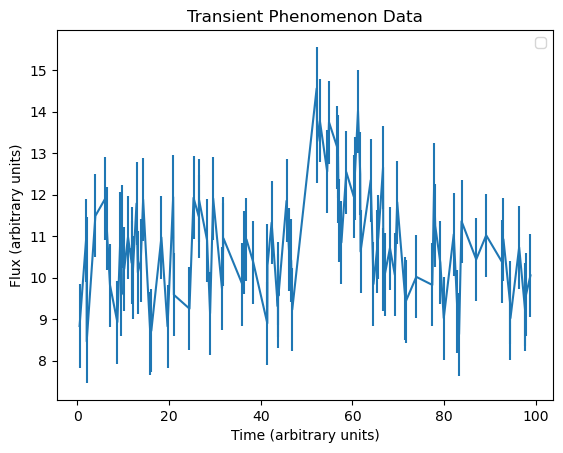

In [1]:
#Exercise L11 

import numpy as np 
import matplotlib.pyplot as plt 
import corner 

data = np.load('C:/Users/user/Desktop/astrostatistics_bicocca_2026/solutions/transient.npy')
t , flux, unc = data[:,0], data[:,1], data[:,2]

plt.errorbar(t, flux, yerr=unc)
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Flux (arbitrary units)")
plt.title("Transient Phenomenon Data")
plt.legend()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_14332\2738042849.py:19: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < np.log(alpha) < 5:


Median: [10.30529562  5.61674866 49.01637843  0.12783125]
90% Credible Region: [[10.14679823  3.98773696 47.24251151  0.09701693]
 [10.46086484  8.29669218 51.44472395  0.16924543]]


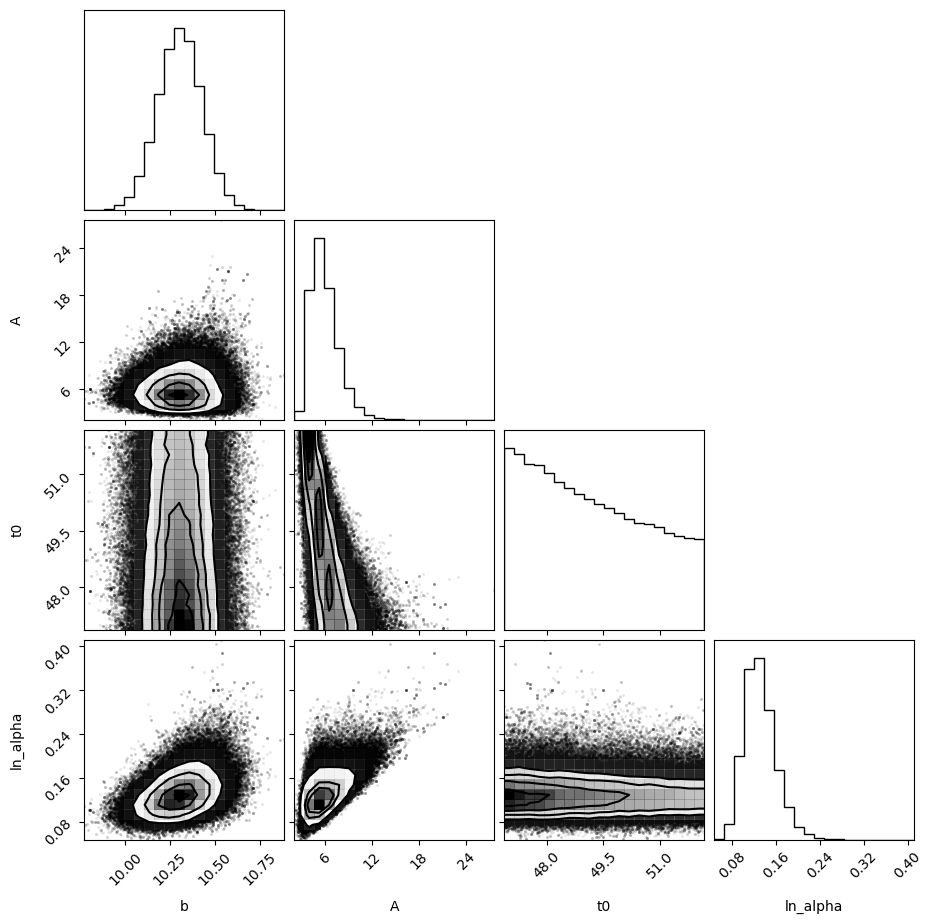

In [3]:
import emcee

# model

def burst_model(t, b, A, t0, alpha):
    return b + A * np.exp(-alpha * (t - t0)) * (t >= t0)

# likelihood function

def log_likelihood(theta, x, y, yerr):
    b, A, t0, alpha = theta
    model = burst_model(x, b, A, t0, alpha)
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

# prior function

def log_prior(theta):
    b, A, t0, alpha = theta
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < np.log(alpha) < 5:
        return 0.0
    return -np.inf

# posterior function

def log_posterior(theta, x, y, yerr):
    return log_prior(theta) + log_likelihood(theta, x, y, yerr)


initial_guess = [10, 10, 50, 0.1]
n_samples = 10000
n_walkers = 50
n_dim = 4
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_dim)

#emcee sampler

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(t, flux, unc))

sampler.run_mcmc(pos, n_samples)

posterior_samples = sampler.get_chain(discard=1000, flat=True)

#corner plot

corner.corner(posterior_samples, labels=["b", "A", "t0", "ln_alpha"])

#median and 90% credible region

median = np.median(posterior_samples, axis=0)

cri = np.percentile(posterior_samples, [10, 90], axis=0)

#results

print("Median:", median)
print("90% Credible Region:", cri)